In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
sys.path.append("../src")

from predict import LinkFailurePredictor

In [11]:
# Load dataset 

DATASET_PATH = "../dataset/manet_dataset.csv"

df = pd.read_csv(DATASET_PATH)

print("Rows:", len(df))
print("Unique runs:", df["run_id"].nunique())
print("Unique timestamps:", df["time"].nunique())

df.head()

Rows: 54000
Unique runs: 30
Unique timestamps: 60


,run_id,time,node_id,x,y,neighbor_count,avg_rssi,tx_packets,rx_packets,lost_packets,delay_sum,link_failure
0,9,1.0,0.0,72.955,1.839,1.0,-3.993,0,0,0,0.0,1
1,9,1.0,1.0,477.050,418.620,3.0,-37.570,0,0,0,0.0,0
2,9,1.0,2.0,22.462,160.934,2.0,-41.436,0,0,0,0.0,1
3,9,1.0,3.0,477.311,378.324,2.0,-35.513,0,0,0,0.0,0
4,9,1.0,4.0,272.095,354.846,0.0,-1000.000,0,0,0,0.0,1


In [12]:
# Initialize ML predictor

predictor = LinkFailurePredictor()

print("Predictor ready")

Loading models...
Models loaded successfully.
Predictor ready


In [ ]:
# Graph builder - this reconstructs the network topology at each time step

def build_graph(snapshot, radius = 100):

    G = nx.Graph()

    rows = snapshot.to_dict("records")

    for r in rows:
        G.add_node(int(r["node_id"]), x = r["x"], y = r["y"])

    edge_features = []
    edge_pairs = []

    for i in range(len(rows)):
        for j in range(i+1, len(rows)):

            n1 = int(rows[i]["node_id"])
            n2 = int(rows[j]["node_id"])

            x1,y1 = rows[i]["x"], rows[i]["y"]
            x2,y2 = rows[j]["x"], rows[j]["y"]

            dist = np.sqrt((x1-x2)**2 + (y1-y2)**2)

            if dist <= radius:

                features = [
                    rows[i]["neighbor_count"],
                    rows[i]["x"],
                    rows[i]["y"],
                    rows[i]["time"]
                ]

                edge_pairs.append((n1,n2))
                edge_features.append(features)

    if len(edge_features) > 0:

        X = np.array(edge_features)

        reliabilities,_ = predictor.predict(X)

        for (u,v),r in zip(edge_pairs,reliabilities):

            r = float(r)

            weight = 1/(r+1e-9)

            G.add_edge(u,v,reliability = r,weight = weight)

    return G

In [ ]:
# Routing metric computation

def route_metrics(G, source, target):

    result = {}

    try:
        baseline = nx.shortest_path(G,source,target)
    except:
        baseline = None

    try:
        ml = nx.shortest_path(G,source,target,weight="weight")
    except:
        ml = None

    result["baseline_path"] = baseline
    result["ml_path"] = ml

    if baseline:

        rel = [G[u][v]["reliability"] for u,v in zip(baseline[:-1],baseline[1:])]

        result["baseline_hops"] = len(baseline) - 1
        result["baseline_mean_rel"] = np.mean(rel)
        result["baseline_min_rel"] = np.min(rel)

    if ml:

        rel = [G[u][v]["reliability"] for u,v in zip(ml[:-1],ml[1:])]

        result["ml_hops"] = len(ml) - 1
        result["ml_mean_rel"] = np.mean(rel)
        result["ml_min_rel"] = np.min(rel)

    return result

In [10]:
# Evaluate across all timestamps

SOURCE = 0
TARGET = 5

times = sorted(df["time"].unique())

records = []

prev_baseline = None
prev_ml = None

for t in tqdm(times):

    snapshot = df[df["time"] == t]

    G = build_graph(snapshot)

    metrics = route_metrics(G,SOURCE,TARGET)

    metrics["time"] = t

    records.append(metrics)

results = pd.DataFrame(records)

results = results.dropna(subset = ["baseline_mean_rel","ml_mean_rel"])

results.head()

100%|██████████| 60/60 [00:32<00:00,  1.84it/s]


,baseline_path,ml_path,time,baseline_hops,baseline_mean_rel,baseline_min_rel,ml_hops,ml_mean_rel,ml_min_rel
6,"[0, 20, 24, 8, 28, 5]","[0, 20, 24, 6, 29, 11, 5]",7.0,5.0,0.606683,0.360758,6.0,0.761862,0.360758
7,"[0, 16, 24, 8, 11, 5]","[0, 20, 24, 29, 11, 5]",8.0,5.0,0.602986,0.367190,5.0,0.722988,0.360889
8,"[0, 25, 8, 11, 5]","[0, 20, 24, 28, 11, 5]",9.0,4.0,0.510073,0.358742,5.0,0.715985,0.350011
9,"[0, 16, 8, 11, 5]","[0, 25, 28, 11, 5]",10.0,4.0,0.500382,0.343153,4.0,0.652578,0.343153
10,"[0, 28, 11, 5]","[0, 28, 11, 5]",11.0,3.0,0.556790,0.350977,3.0,0.556790,0.350977


In [13]:
baseline_mean = results["baseline_mean_rel"].mean()
ml_mean = results["ml_mean_rel"].mean()

baseline_min = results["baseline_min_rel"].mean()
ml_min = results["ml_min_rel"].mean()

baseline_hops = results["baseline_hops"].mean()
ml_hops = results["ml_hops"].mean()

improvement = (ml_mean-baseline_mean)/baseline_mean*100

print("Average baseline reliability:",round(baseline_mean,3))
print("Average ML reliability:",round(ml_mean,3))
print("Reliability improvement:",round(improvement,2),"%")

print()

print("Average baseline hops:",round(baseline_hops,2))
print("Average ML hops:",round(ml_hops,2))

Average baseline reliability: 0.658
Average ML reliability: 0.723
Reliability improvement: 9.75 %

Average baseline hops: 3.75
Average ML hops: 3.82


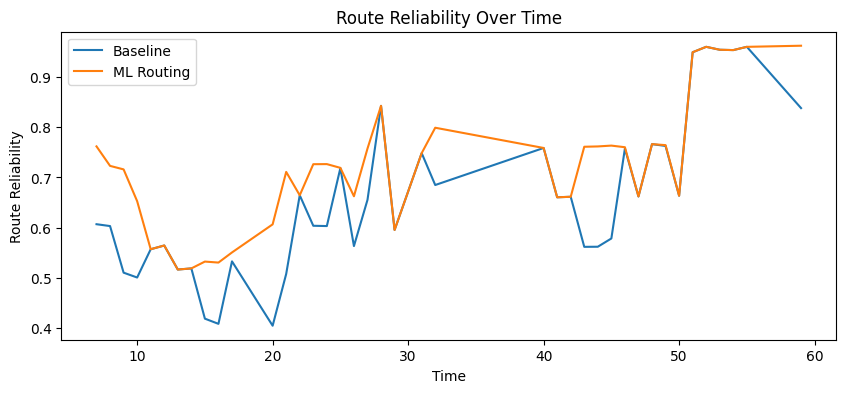

In [14]:
plt.figure(figsize=(10,4))

plt.plot(results["time"],results["baseline_mean_rel"],label="Baseline")
plt.plot(results["time"],results["ml_mean_rel"],label="ML Routing")

plt.xlabel("Time")
plt.ylabel("Route Reliability")

plt.title("Route Reliability Over Time")

plt.legend()
plt.show()

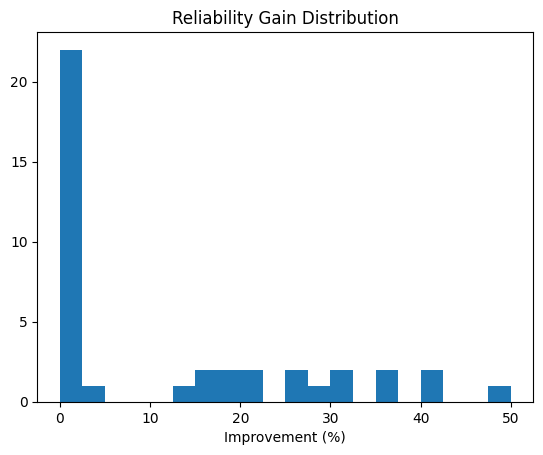

In [15]:
results["gain_pct"] = (
    (results["ml_mean_rel"] - results["baseline_mean_rel"])
    / results["baseline_mean_rel"]
) * 100

plt.hist(results["gain_pct"].dropna(),bins = 20)

plt.title("Reliability Gain Distribution")
plt.xlabel("Improvement (%)")

plt.show()